In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Callable, Iterable

In [2]:
generator = np.random.default_rng(15)

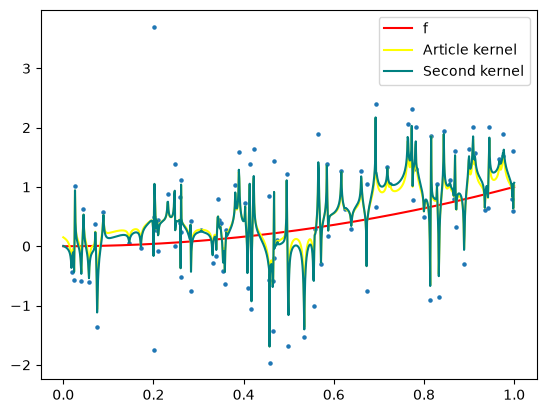

In [3]:
class NW_estimator:
    def __init__(
        self,
        kernel: Callable[[np.ndarray], float],
        scale: float,
        features: np.ndarray,
        labels: np.ndarray,
    ):
        self._kernel: Callable[[np.ndarray], float] = kernel
        self._scale: float = scale
        self._features: np.ndarray = features
        self._labels: np.ndarray = labels

    def __call__(self, features: np.ndarray) -> float:
        result: float = 0.0
        length: int = len(self._labels)
        kernel_evaluations: np.ndarray = np.empty(length)
        for k, x, y in zip(range(length), self._features, self._labels):
            if (features == x).all():
                return y
            evaluation: float = self._kernel((features - x) / self._scale)
            kernel_evaluations[k] = evaluation
            result += y * evaluation
        return result / np.sum(kernel_evaluations)

    def add_data(self, features, labels) -> None:
        self._features = np.stack(self._features, features)
        self._labels = np.stack(self._labels, labels)

    def compute_MSE(
        self,
        func: Callable[[np.ndarray | float], np.ndarray | float],
        x_range: Tuple(float | int, float | int, float | int),
    ) -> float:
        T: np.ndarray = np.linspace(x_range[0], x_range[1], int(x_range[2]))
        true_func: np.ndarray | float = func(T)
        estimations = np.array([self(t) for t in T])
        return np.linalg.norm((true_func - estimations)) ** 2 / x_range[2]


def one_dim_simulation(
    func: Callable[[np.ndarray | float], float],
    kernels: List[Callable[[np.ndarray | float], float]],
    kernels_labels: List[str],
    num_sampling: int,
    noise: float,
    scale: float,
    x_range: Tuple(float | int, float | int, float | int),
) -> None:
    colors: List[str] = ["yellow", "teal", "green", "purple"]
    T = np.linspace(x_range[0], x_range[1], int(x_range[2]))
    X = generator.random(num_sampling)
    true_func = func(T)
    Y = func(X) + noise * np.random.randn(num_sampling)
    plt.plot(T, true_func, color="red", label="f")
    plt.scatter(X, Y, s=5)
    for k, kernel, label in zip(range(num_sampling), kernels, kernels_labels):
        estimator: NW_estimator = NW_estimator(kernel, scale, X, Y)
        estimations = np.array([estimator(t) for t in T])
        plt.plot(T, estimations, color=colors[k % 4], label=label)
    plt.legend()
    plt.show()


def article_kernel(x: float, alpha: float) -> float:
    if abs(x) > 1:
        return 0
    return 1 / abs(x) ** alpha


def second_kernel(x: float, alpha: float) -> float:
    if abs(x) > 1:
        return 0
    return (1 - abs(x)) ** 2 * abs(x) ** -alpha


one_dim_simulation(
    lambda x: x**2,
    [lambda x: article_kernel(x, 1.0), lambda x: second_kernel(x, 1.0)],
    ["Article kernel", "Second kernel"],
    100,
    1.0,
    1.0,
    (0, 1, 1e3),
)

In [4]:
def compute_MSE(
    func: Callable[[np.ndarray | float], np.ndarray | float],
    kernel: Callable[[np.ndarray | float], float],
    num_sampling: int,
    noise: float,
    scale: float,
    x_range: Tuple(float | int, float | int, float | int),
) -> float:
    T: np.ndarray = np.linspace(x_range[0], x_range[1], int(x_range[2]))
    true_func: np.ndarray | float = func(T)
    X: np.ndarray = generator.random(num_sampling)
    Y: np.ndarray = X + noise * np.random.randn(num_sampling)
    estimator: NW_estimator = NW_estimator(kernel, scale, X, Y)
    estimations = np.array([estimator(t) for t in T])
    return np.linalg.norm((true_func - estimations)) ** 2 / x_range[2]


compute_MSE(
    lambda x: x**2, lambda x: article_kernel(x, 1.0), 100, 1.0, 1.0, (0, 1, 1e3)
)

np.float64(0.21610856004131923)

Thread: 1 launched
(4,)
0 10 0
Thread: 2 launched
(4,)
0 10 1
Thread: 3 launched
(4,)
0 10 2
Thread: 4 launched
(4,)
0 10 3
Thread: 5 launched
(4,)
0 10 4
Thread: 6 launched
(4,)
0 10 5
Thread: 7 launched
(4,)
0 10 6
Thread: 8 launched
(4,)
0 10 7
Thread: 9 launched
(4,)
0 10 8
Thread: 10 launched
(4,)
0 10 9
1 10 0
1 10 1
1 10 2
1 10 3
1 10 4
1 10 5
1 10 6
1 10 7
1 10 8
1 10 9
2 10 0
2 10 1
2 10 2
2 10 3
2 10 4
2 10 5
2 10 6
2 10 7
2 10 8
2 10 9
3 10 0
3 10 1
3 10 2
3 10 3
3 10 4
3 10 5
3 10 6
3 10 7
3 10 8
3 10 9


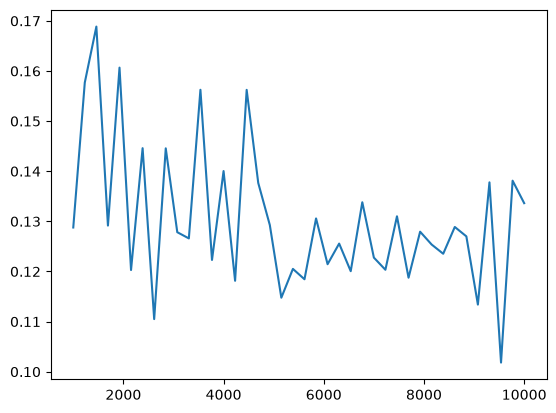

In [16]:
import threading

sampling = np.linspace(1_000, 10_000, 40, dtype=int)
errors = np.zeros(len(sampling))

NUM_THREADS: int = 8


def get_MSE(
    func: Callable[[np.ndarray | float], np.ndarray | float],
    kernel: Callable[[np.ndarray | float], float],
    kernel_label: str,
    sampling: Iterable[int],
    noise: float,
    scale: float,
    x_range: tuple(float | int, float | int, float | int),
    thread_index: int = 0,
) -> None:
    l: int = len(sampling)
    print(f"Thread: {thread_index + 1} launched")
    for i, sample in enumerate(sampling[thread_index::NUM_THREADS]):
        print(i, NUM_THREADS, thread_index)
        k_index = i * NUM_THREADS + thread_index
        errors[k_index] = compute_MSE(func, kernel, sample, noise, scale, x_range)


def plot_MSE(
    func: Callable[[np.ndarray | float], np.ndarray | float],
    kernel: Callable[[np.ndarray | float], float],
    kernel_label: str,
    sampling: Iterable[int],
    noise: float,
    scale: float,
    x_range: tuple[float | int, float | int, float | int],
    save_file: str | None = None,
):
    threads = []
    for i in range(NUM_THREADS):
        threads.append(
            threading.Thread(
                target=get_MSE,
                args=(func, kernel, kernel_label, sampling, noise, scale, x_range, i),
            )
        )

    for thread in threads:
        thread.start()

    for thread in threads:
        thread.join()

    plt.plot(sampling, errors)
    plt.show()


plot_MSE(
    lambda x: x**2,
    lambda x: article_kernel(x, 1.0),
    "Article kernel",
    sampling,
    1.0,
    1.0,
    (0, 1, 1e3),
)

In [ ]:
scales = np.linspace(0.1, 10, 40)
mistakes = []
for scale in scales:
    pred = np.array([SA_classifier(X_i, scale) for X_i in X_test])
    mistakes.append(93 - np.count_nonzero(pred == Y_test))


plt.plot(scales, mistakes)
print(mistakes[20], scales[20])

In [ ]:
X, Y = np.meshgrid(np.arange(0, 31.5, 1), np.arange(0, 150, 1))
XY = np.stack((X, Y), axis=-1).reshape(-1, 2)
Z = np.array([SA_classifier(X_i, 5.2) for X_i in XY]).reshape(X.shape)
fig, ax = plt.subplots(figsize=(13, 8))
ax.contourf(X, Y, Z)
plt.scatter(X_train[Y_train == 1][:, 0], X_train[Y_train == 1][:, 1], s=3, c="red")
plt.scatter(X_train[Y_train == -1][:, 0], X_train[Y_train == -1][:, 1], s=3, c="blue")
plt.scatter(X_test[Y_test == 1][:, 0], X_test[Y_test == 1][:, 1], s=3, c="orange")
plt.scatter(X_test[Y_test == -1][:, 0], X_test[Y_test == -1][:, 1], s=3, c="green")

In [ ]:
X, Y = np.meshgrid(np.arange(0, 31.5, 0.05), np.arange(0, 150, 0.05))

XY = np.stack((X, Y), axis=-1).reshape(-1, 2)
Z = np.array([SA_classifier(X_i, 5.2) for X_i in XY]).reshape(X.shape)


fig, ax = plt.subplots(figsize=(13, 8))
ax.contourf(X, Y, Z)
plt.scatter(X_train[Y_train == 1][:, 0], X_train[Y_train == 1][:, 1], s=3, c="red")
plt.scatter(X_train[Y_train == -1][:, 0], X_train[Y_train == -1][:, 1], s=3, c="blue")

In [ ]:
def gaussian_2D(x: np.ndarray, mu: np.ndarray, sigma: float) -> float:
    return np.exp(-np.linalg.norm(x - mu) / (2 * sigma**2)) / (2 * np.pi * sigma)

In [ ]:
n: int = 1_300
X_train = rd.uniform(0.2, 0.8, (n, 2))
Y_train = np.zeros(n)

n_test: int = 250
X_test = rd.uniform(0.2, 0.8, (n_test, 2))
Y_test = np.zeros(n_test)

for i, x in enumerate(X_train):
    Y_train[i] = rd.choice(
        [-1, 1],
        p=[
            1 - gaussian_2D(x, np.array([0.5, 0.5]), 0.2),
            gaussian_2D(x, np.array([0.5, 0.5]), 0.2),
        ],
    )

for i, x in enumerate(X_test):
    Y_test[i] = rd.choice(
        [-1, 1],
        p=[
            1 - gaussian_2D(x, np.array([0.5, 0.5]), 0.2),
            gaussian_2D(x, np.array([0.5, 0.5]), 0.2),
        ],
    )

estimator = NW_Estimator(first_kernel, 1, 0.05, X_train, Y_train)
predictions = np.array([estimator(X_i) for X_i in X_test])

X, Y = np.meshgrid(np.linspace(0.2, 0.8, 100), np.linspace(0.2, 0.8, 100))
XY = np.stack((X, Y), axis=-1).reshape(-1, 2)
Z = np.array([estimator(X_i) for X_i in XY]).reshape(X.shape)

fig, ax = plt.subplots(figsize=(13, 8))
ax.contourf(X, Y, Z)
true_prob = np.array(
    [gaussian_2D(X_i, np.array([0.5, 0.5]), 0.2) for X_i in XY]
).reshape(X.shape)
contour_line = ax.contour(
    X, Y, true_prob, levels=[0.5], colors="black", linewidths=2, linestyles="dashed"
)
plt.scatter(X_train[Y_train == 1][:, 0], X_train[Y_train == 1][:, 1], s=2, c="red")
plt.scatter(X_train[Y_train == -1][:, 0], X_train[Y_train == -1][:, 1], s=2, c="blue")
plt.scatter(
    X_test[predictions == 1][:, 0], X_test[predictions == 1][:, 1], s=7, c="orange"
)
plt.scatter(
    X_test[predictions == -1][:, 0], X_test[predictions == -1][:, 1], s=7, c="green"
)

In [ ]:
def f(x: np.ndarray) -> float:
    t = x[0]
    return (-(t**2) / 16 + 0.5) / 0.833


n: int = 1_300
X_train = np.random.uniform(0, 2, (n, 2))
Y_train = np.zeros(n)

n_test: int = 250
X_test = np.random.uniform(0, 2, (n_test, 2))
Y_test = np.zeros(n_test)

for i, x in enumerate(X_train):
    Y_train[i] = np.random.choice([-1, 1], p=[1 - f(x), f(x)])

for i, x in enumerate(X_test):
    Y_test[i] = np.random.choice([-1, 1], p=[1 - f(x), f(x)])

estimator = NW_Estimator(first_kernel, 1, 0.05, X_train, Y_train)
predictions = np.array([estimator(X_i) for X_i in X_test])

X, Y = np.meshgrid(np.linspace(0, 2, 150), np.linspace(0, 2, 150))
XY = np.stack((X, Y), axis=-1).reshape(-1, 2)
Z = np.array([estimator(X_i) for X_i in XY]).reshape(X.shape)

fig, ax = plt.subplots(figsize=(13, 8))
ax.contourf(X, Y, Z)
true_prob = np.array([f(X_i) for X_i in XY]).reshape(X.shape)
contour_line = ax.contour(
    X, Y, true_prob, levels=[0.5], colors="black", linewidths=2, linestyles="dashed"
)
plt.scatter(
    X_train[Y_train == 1][:, 0],
    X_train[Y_train == 1][:, 1],
    s=2,
    c="red",
    label="Données d'entraînement: classe 1",
)
plt.scatter(
    X_train[Y_train == -1][:, 0],
    X_train[Y_train == -1][:, 1],
    s=2,
    c="blue",
    label="Données d'entraînement: classe 2",
)
plt.scatter(
    X_test[predictions == 1][:, 0],
    X_test[predictions == 1][:, 1],
    s=7,
    c="orange",
    label="Données de test: classe 1",
)
plt.scatter(
    X_test[predictions == -1][:, 0],
    X_test[predictions == -1][:, 1],
    s=7,
    c="green",
    label="Données de test: classe 2",
)
plt.legend()
plt.show()

In [ ]:
X = np.linspace(0, 5, 100)
X2 = np.linspace(0.5, 4.5, 100)
Y1 = np.power(X, 2)
Y2 = np.power(5 - X, 2)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(X, Y1)
ax[0].vlines(1, -13, 1, colors="blue", linestyles="dashed")
ax[0].vlines(4, -13, 16, colors="blue", linestyles="dashed")
ax[0].hlines(1, 0, 1, colors="red", linestyles="dashed")
ax[0].hlines(16, 0, 4, colors="red", linestyles="dashed")
ax[0].plot(X2, 8 * (X2 - 4) + 16, color="orange", label="tangent line")
ax[0].hlines(-8, 0, 1, color="orange", linestyles="dashed")

ax[1].plot(X, Y2)
ax[1].vlines(1, -13, 16, colors="blue", linestyles="dashed")
ax[1].vlines(4, -13, 1, colors="blue", linestyles="dashed")
ax[1].hlines(1, 0, 4, colors="red", linestyles="dashed")
ax[1].hlines(16, 0, 1, colors="red", linestyles="dashed")
ax[1].plot(X2, 2 * (4 - X2) + 1, color="orange", label="tangent line")
ax[1].hlines(7, 0, 1, color="orange", linestyles="dashed")

plt.show()

- Cas simple (hyperplan séparateur)
- Préciser forme du noyau
- Chapeau du f
- Trouver la clé de la démonstration

In [ ]:
def first_kernel(x: np.ndarray, alpha: float) -> float:
    if np.linalg.norm(x) <= 1:
        return np.pow(np.linalg.norm(x), -alpha)
    return 0


def second_kernel(x: np.ndarray, alpha: float) -> float:
    if np.linalg.norm(x) <= 1:
        return np.pow(np.linalg.norm(x), -alpha) * np.pow((1 - np.linalg.norm(x)), 2)
    return 0


def gaussian_2D(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    return np.exp(np.transpose(x - mu).dot(np.linalg.inv(sigma).dot(x - mu)))


mu1: np.ndarray = np.array([0.5, 0.5])
mu2: np.ndarray = -np.array([0.5, 0.5])
sigma: np.ndarray = np.array([[0.5, 0], [0, 0.5]])

num_sample: int = 500
class1 = np.random.multivariate_normal(mu1, sigma, num_sample)
class2 = np.random.multivariate_normal(mu2, sigma, num_sample)
classifier = NW_Estimator(
    first_kernel,
    1,
    0.05,
    np.concatenate((class1, class2)),
    np.concatenate((np.ones(num_sample), -np.ones(num_sample))),
)

num_test: int = 100
test1 = np.random.multivariate_normal(mu1, sigma, num_test)
test2 = np.random.multivariate_normal(mu2, sigma, num_test)

classifier_estimations = classifier(np.concatenate((test1, test2)))
bayes_estimations = np.array(
    [
        1 if gaussian_2D(X_i, mu1, sigma) >= gaussian_2D(X_i, mu2, sigma) else -1
        for X_i in np.concatenate((test1, test2))
    ]
)

bayes_accuracy, classifier_accuracy = (
    np.count_nonzero(
        bayes_estimations == np.concatenate((np.ones(num_test), -np.ones(num_test)))
    )
    / 200,
    np.count_nonzero(
        classifier_estimations
        == np.concatenate((np.ones(num_test), -np.ones(num_test)))
    )
    / 200,
)

X, Y = np.meshgrid(np.linspace(-4, 4, 120), np.linspace(-4, 4, 120))
XY = np.stack((X, Y), axis=-1).reshape(-1, 2)
Z = np.array([classifier(X_i) for X_i in XY]).reshape(X.shape)

fig, ax = plt.subplots(figsize=(13, 8))
ax.contourf(X, Y, Z)
plt.title(
    f"Classification modèle linéaire gaussien, N={num_sample} données d'éntraînement par classe"
)
plt.scatter(
    class1[:, 0], class1[:, 1], s=4, c="red", label="Données d'entraînement: classe 1"
)
plt.scatter(
    class2[:, 0], class2[:, 1], s=4, c="blue", label="Données d'entraînement: classe 2"
)
plt.scatter(
    test1[:, 0], test1[:, 1], s=5, c="orange", label="Données de test: classe 1"
)
plt.scatter(test2[:, 0], test2[:, 1], s=5, c="green", label="Données de test: classe 2")
plt.legend()